# MBAN5570 – Assignment 4, Question II
## ML Application to Predicting Stock Prices using ARIMA

**Stock Selected:** Apple Inc. (AAPL)  
**Data Source:** Yahoo Finance via `yfinance` library  
**Time Period:** January 1, 2020 – January 1, 2025 (5 years of daily data)  
**Model:** Auto-ARIMA (pmdarima) — automatically selects optimal (p, d, q) parameters

### Why Apple?
As an Apple (AAPL) share holder, it was also selected because it is one of the most widely traded stocks in the world and occupies the middle ground in the AI revolution — as established in Question I (AI Intensity: 4.14%). Its price history over 2020–2025 captures a rich variety of
market conditions: the COVID-19 crash and recovery, the 2022 tech selloff, and the
subsequent rebound driven by Services growth and Apple Intelligence. This makes it
an excellent candidate for time-series forecasting.

### Objective
1. Download historical adjusted closing prices using `yfinance`
2. Split data into 80% training / 20% testing sets
3. Fit an ARIMA model using `auto_arima` to select optimal (p, d, q) parameters
4. Evaluate model performance using Root Mean Squared Error (RMSE)
5. Visualize predicted vs actual prices
6. Predict the adjusted closing price for a future date not in the dataset
7. Make a **Buy / Sell / Hold** recommendation based on the prediction

## Step 0 – Install and Import Libraries

We install `yfinance` to download stock price data and `pmdarima` for the Auto-ARIMA
model. All other libraries (pandas, numpy, matplotlib, sklearn, statsmodels) come
pre-installed in Google Colab.

In [1]:
# Install required libraries
!pip install yfinance pmdarima -q
print('Installation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.4 MB/s eta 0:00:00
Installation complete.


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Modelling imports ──────────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pmdarima as pm
from datetime import datetime, timedelta

# ── Plot styling ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.family'      : 'sans-serif'
})

print('All libraries imported successfully.')
print(f'pmdarima version : {pm.__version__}')
print(f'yfinance version : {yf.__version__}')

All libraries imported successfully.
pmdarima version : 2.1.1
yfinance version : 0.2.66


## Step 1 – Data Collection

We use `yfinance` to download **5 years of daily adjusted closing prices** for Apple (AAPL),
from January 1, 2020 to January 1, 2025. This window captures four distinct market phases:
- **2020:** COVID-19 crash and rapid recovery
- **2021:** Post-pandemic tech boom, Apple hits $3 trillion market cap
- **2022:** Tech selloff driven by interest rate hikes
- **2023–2024:** Recovery driven by Services growth and Apple Intelligence announcements

Setting `auto_adjust=True` means the 'Close' column already reflects dividend and
split adjustments — producing a clean, consistent series suitable for forecasting.

In [3]:
# ── Download stock data ────────────────────────────────────────────────────
TICKER     = 'AAPL'
START_DATE = '2020-01-01'
END_DATE   = '2025-01-01'

print(f'Downloading {TICKER} data from {START_DATE} to {END_DATE}...')
df = yf.download(TICKER, start=START_DATE, end=END_DATE,
                 auto_adjust=True, progress=False)

print(f'Downloaded {len(df):,} trading days of data.')
print(f'Date range : {df.index[0].date()} to {df.index[-1].date()}')
print(f'\nFirst 3 rows:')
print(df.head(3))
print(f'\nLast 3 rows:')
print(df.tail(3))

Downloaded 1,258 trading days of data.
Date range : 2020-01-02 to 2024-12-31

First 3 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267921  72.306491  70.568495  70.819193  118387200

Last 3 rows:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-27  254.201355  257.294474  251.685102  256.429175  42355300
2024-12-30  250.829773  252.122713  249.387654  250.859609  35557500
2024-12-31  249.059464  251.903926  248.074837  251.068493  39480700


In [4]:
# ── Extract adjusted closing price as a pandas Series ─────────────────────
# With auto_adjust=True, the 'Close' column IS the adjusted close price
stock_price        = df['Close']
stock_price_series = pd.Series(
    stock_price.values.flatten(),
    index=df.index,
    name='Adj Close (AAPL)'
)

# Check for and handle any missing values
missing = stock_price_series.isna().sum()
print(f'Missing values detected: {missing}')
if missing > 0:
    stock_price_series = stock_price_series.fillna(method='ffill')
    print('  Forward-fill applied to missing values.')

print(f'\nAAPL Price Summary (2020–2025)')
print(f'  Start price  : ${stock_price_series.iloc[0]:.2f}  ({stock_price_series.index[0].date()})')
print(f'  End price    : ${stock_price_series.iloc[-1]:.2f}  ({stock_price_series.index[-1].date()})')
print(f'  Min price    : ${stock_price_series.min():.2f}')
print(f'  Max price    : ${stock_price_series.max():.2f}')
print(f'  Total return : {((stock_price_series.iloc[-1]/stock_price_series.iloc[0])-1)*100:.1f}%')
print(f'  Observations : {len(stock_price_series):,} trading days')

Missing values detected: 0

AAPL Price Summary (2020–2025)
  Start price  : $72.40  (2020-01-02)
  End price    : $249.06  (2024-12-31)
  Min price    : $54.21
  Max price    : $257.61
  Total return : 244.0%
  Observations : 1,258 trading days


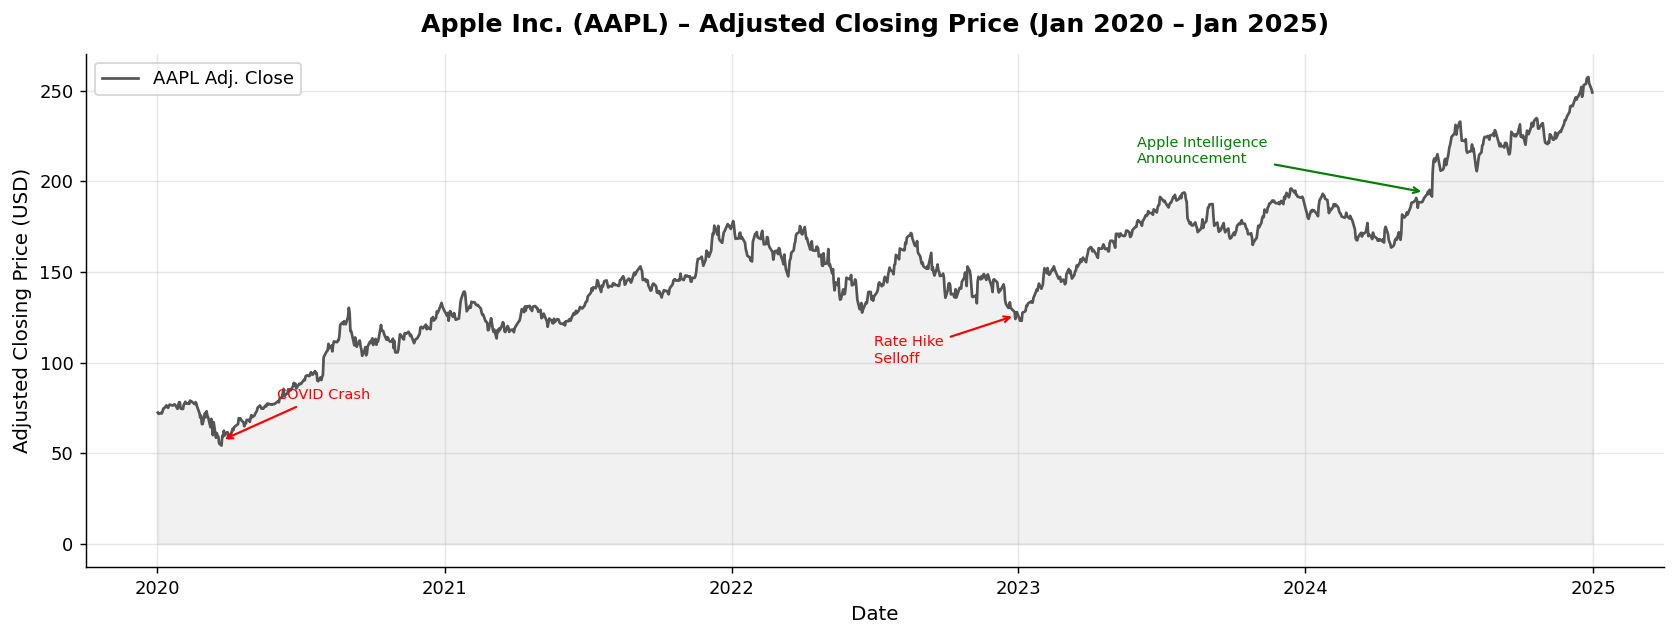

Saved: aapl_price_history.png


In [5]:
# ── Plot full price history ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(stock_price_series.index, stock_price_series.values,
        color='#555555', linewidth=1.5, label='AAPL Adj. Close')
ax.fill_between(stock_price_series.index, stock_price_series.values,
                alpha=0.08, color='#555555')

# Annotate key events
ax.annotate('COVID Crash', xy=(pd.Timestamp('2020-03-23'), 57),
            xytext=(pd.Timestamp('2020-06-01'), 80),
            fontsize=8, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.annotate('Rate Hike\nSelloff', xy=(pd.Timestamp('2022-12-28'), 126),
            xytext=(pd.Timestamp('2022-07-01'), 100),
            fontsize=8, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.annotate('Apple Intelligence\nAnnouncement', xy=(pd.Timestamp('2024-06-01'), 194),
            xytext=(pd.Timestamp('2023-06-01'), 210),
            fontsize=8, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

ax.set_title('Apple Inc. (AAPL) – Adjusted Closing Price (Jan 2020 – Jan 2025)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Adjusted Closing Price (USD)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('aapl_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_price_history.png')

## Step 2 – Train/Test Split

The data is split into **80% training** and **20% testing** using `train_test_split`
with `shuffle=False`. This is critical for time-series data — shuffling would cause
**data leakage**, where future prices inform past predictions, producing misleadingly
optimistic results.

- **Training set (~80%):** The model learns price patterns from this data
- **Testing set (~20%):** Used to evaluate how well the model forecasts unseen prices

In [6]:
# ── 80/20 chronological split — no shuffling ───────────────────────────────
train_data, test_data = train_test_split(
    stock_price_series,
    test_size=0.2,
    shuffle=False      # CRITICAL: keep chronological order
)

print('Train / Test Split Summary')
print('=' * 50)
print(f'Total observations : {len(stock_price_series):,} trading days')
print(f'Training set       : {len(train_data):,} days '
      f'({train_data.index[0].date()} → {train_data.index[-1].date()})')
print(f'Testing set        : {len(test_data):,} days '
      f'({test_data.index[0].date()} → {test_data.index[-1].date()})')
print(f'Training share     : {len(train_data)/len(stock_price_series)*100:.1f}%')
print(f'Testing share      : {len(test_data)/len(stock_price_series)*100:.1f}%')

Train / Test Split Summary
Total observations : 1,258 trading days
Training set       : 1,006 days (2020-01-02 → 2023-12-29)
Testing set        : 252 days (2024-01-02 → 2024-12-31)
Training share     : 80.0%
Testing share      : 20.0%


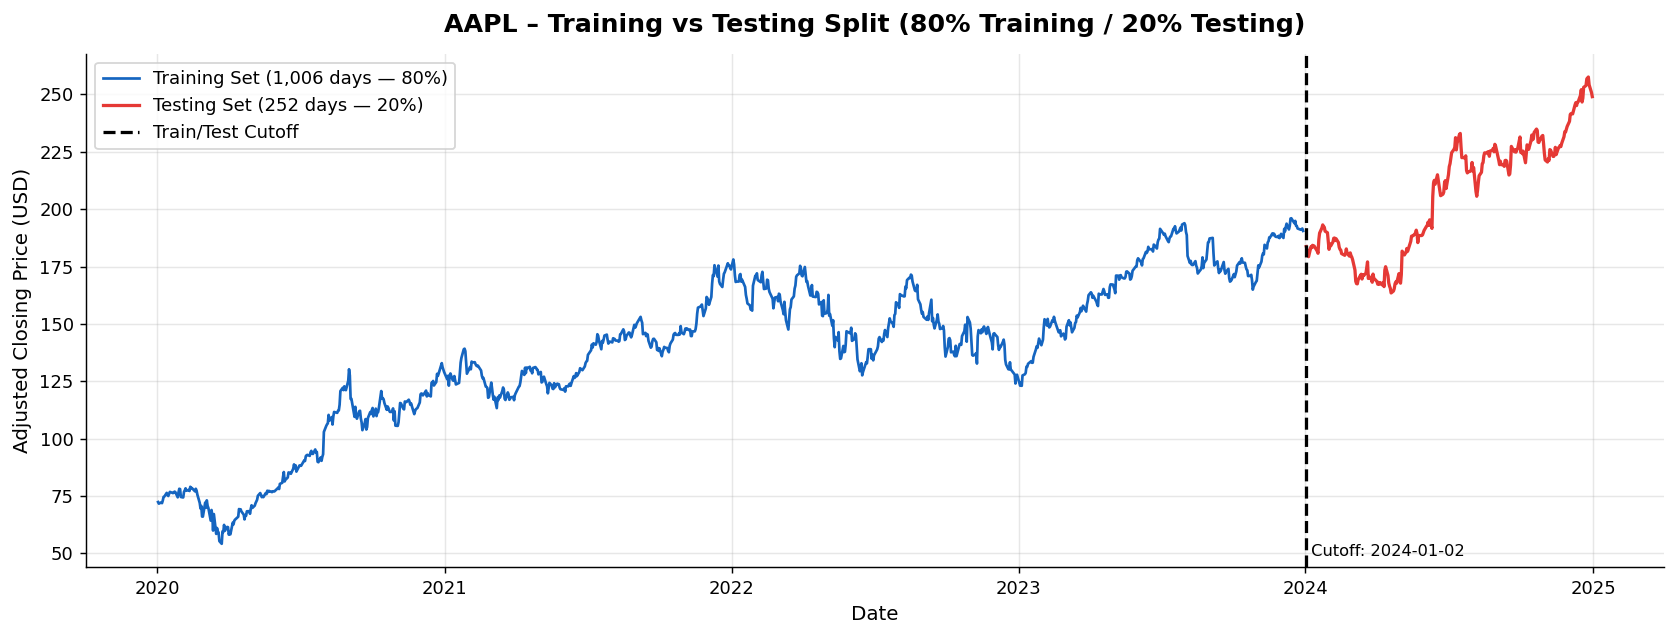

Saved: aapl_train_test_split.png


In [7]:
# ── Visualise train/test split ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train_data.index, train_data.values,
        color='#1565C0', linewidth=1.5,
        label=f'Training Set ({len(train_data):,} days — 80%)')
ax.plot(test_data.index, test_data.values,
        color='#E53935', linewidth=1.8,
        label=f'Testing Set ({len(test_data):,} days — 20%)')
ax.axvline(test_data.index[0], color='black', linestyle='--',
           linewidth=1.8, label='Train/Test Cutoff')
ax.text(test_data.index[0], ax.get_ylim()[0] + 5,
        f' Cutoff: {test_data.index[0].date()}',
        fontsize=9, color='black')

ax.set_title('AAPL – Training vs Testing Split (80% Training / 20% Testing)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Adjusted Closing Price (USD)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('aapl_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_train_test_split.png')

## Step 3 – Build the ARIMA Model

**ARIMA (Autoregressive Integrated Moving Average)** forecasts a time series using
three components:

| Parameter | Name | Meaning |
|---|---|---|
| **p** | AR lags | How many past prices predict the current price |
| **d** | Differencing | How many times the series is differenced to achieve stationarity |
| **q** | MA lags | How many past forecast errors are incorporated |

We use `auto_arima` from `pmdarima` which automatically searches for the best
(p, d, q) combination by minimising the **AIC (Akaike Information Criterion)**.
This avoids the need for manual parameter tuning and is the approach specified
in the assignment.

For daily stock prices:
- `seasonal=False` — stock prices do not have a meaningful seasonal cycle
- `stepwise=True` — efficient parameter search rather than exhaustive grid search
- Stock prices are typically **d=1** (random walk: stationary in returns, not levels)

In [8]:
# ── Fit Auto-ARIMA on training data ───────────────────────────────────────
print('Fitting Auto-ARIMA model on training data...')
print('(This searches for the optimal p, d, q — may take 1-2 minutes)\n')

model = pm.auto_arima(
    train_data,
    seasonal          = False,   # No seasonal component for daily prices
    suppress_warnings = True,    # Clean output
    stepwise          = True,    # Efficient stepwise search
    error_action      = 'ignore',
    max_p             = 5,       # Maximum AR lags
    max_q             = 5,       # Maximum MA lags
    information_criterion = 'aic'  # Select model minimising AIC
)

p, d, q = model.order

print(f'Auto-ARIMA selected: ARIMA({p}, {d}, {q})')
print(f'  p = {p}  →  {p} autoregressive lag(s)')
print(f'  d = {d}  →  {d} degree(s) of differencing (confirms random-walk structure)')
print(f'  q = {q}  →  {q} moving average lag(s)')
print(f'\nModel AIC : {model.aic():.4f}')
print('\n--- Full Model Summary ---')
print(model.summary())

Fitting Auto-ARIMA model on training data...
(This searches for the optimal p, d, q — may take 1-2 minutes)

Auto-ARIMA selected: ARIMA(2, 1, 2)
  p = 2  →  2 autoregressive lag(s)
  d = 1  →  1 degree(s) of differencing (confirms random-walk structure)
  q = 2  →  2 moving average lag(s)

Model AIC : 4756.5346

--- Full Model Summary ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1006
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -2372.267
Date:                Wed, 15 Apr 2026   AIC                           4756.535
Time:                        01:06:56   BIC                           4786.011
Sample:                             0   HQIC                          4767.735
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    st

## Step 4 – Generate Predictions and Evaluate Performance

We predict the adjusted closing price for each of the **252 days in the test set**
(data the model has never seen) and evaluate accuracy using three metrics:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

- **RMSE** — expressed in USD; directly interpretable as the average dollar error
- **MAE** — average absolute error; less sensitive to large individual errors
- **MAPE** — percentage error; useful for comparing across different price scales

In [9]:
# ── Predict on test set ────────────────────────────────────────────────────
predictions = model.predict(n_periods=len(test_data))
predictions_series = pd.Series(
    predictions,
    index=test_data.index,
    name=f'ARIMA({p},{d},{q}) Forecast'
)

# ── Performance metrics ────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(test_data.values, predictions))
mae  = np.mean(np.abs(test_data.values - predictions))
mape = np.mean(np.abs((test_data.values - predictions) / test_data.values)) * 100
avg_test_price = test_data.mean()

print('Model Performance on Test Set (20% Hold-Out)')
print('=' * 48)
print(f'RMSE (Root Mean Squared Error) : ${rmse:.4f}')
print(f'MAE  (Mean Absolute Error)     : ${mae:.4f}')
print(f'MAPE (Mean Abs. % Error)       : {mape:.4f}%')
print()
print(f'Average actual test price      : ${avg_test_price:.2f}')
print(f'RMSE as % of avg test price    : {(rmse/avg_test_price)*100:.2f}%')

Model Performance on Test Set (20% Hold-Out)
RMSE (Root Mean Squared Error) : $17.5938
MAE  (Mean Absolute Error)     : $14.9011
MAPE (Mean Abs. % Error)       : 7.5774%

Average actual test price      : $205.65
RMSE as % of avg test price    : 8.56%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


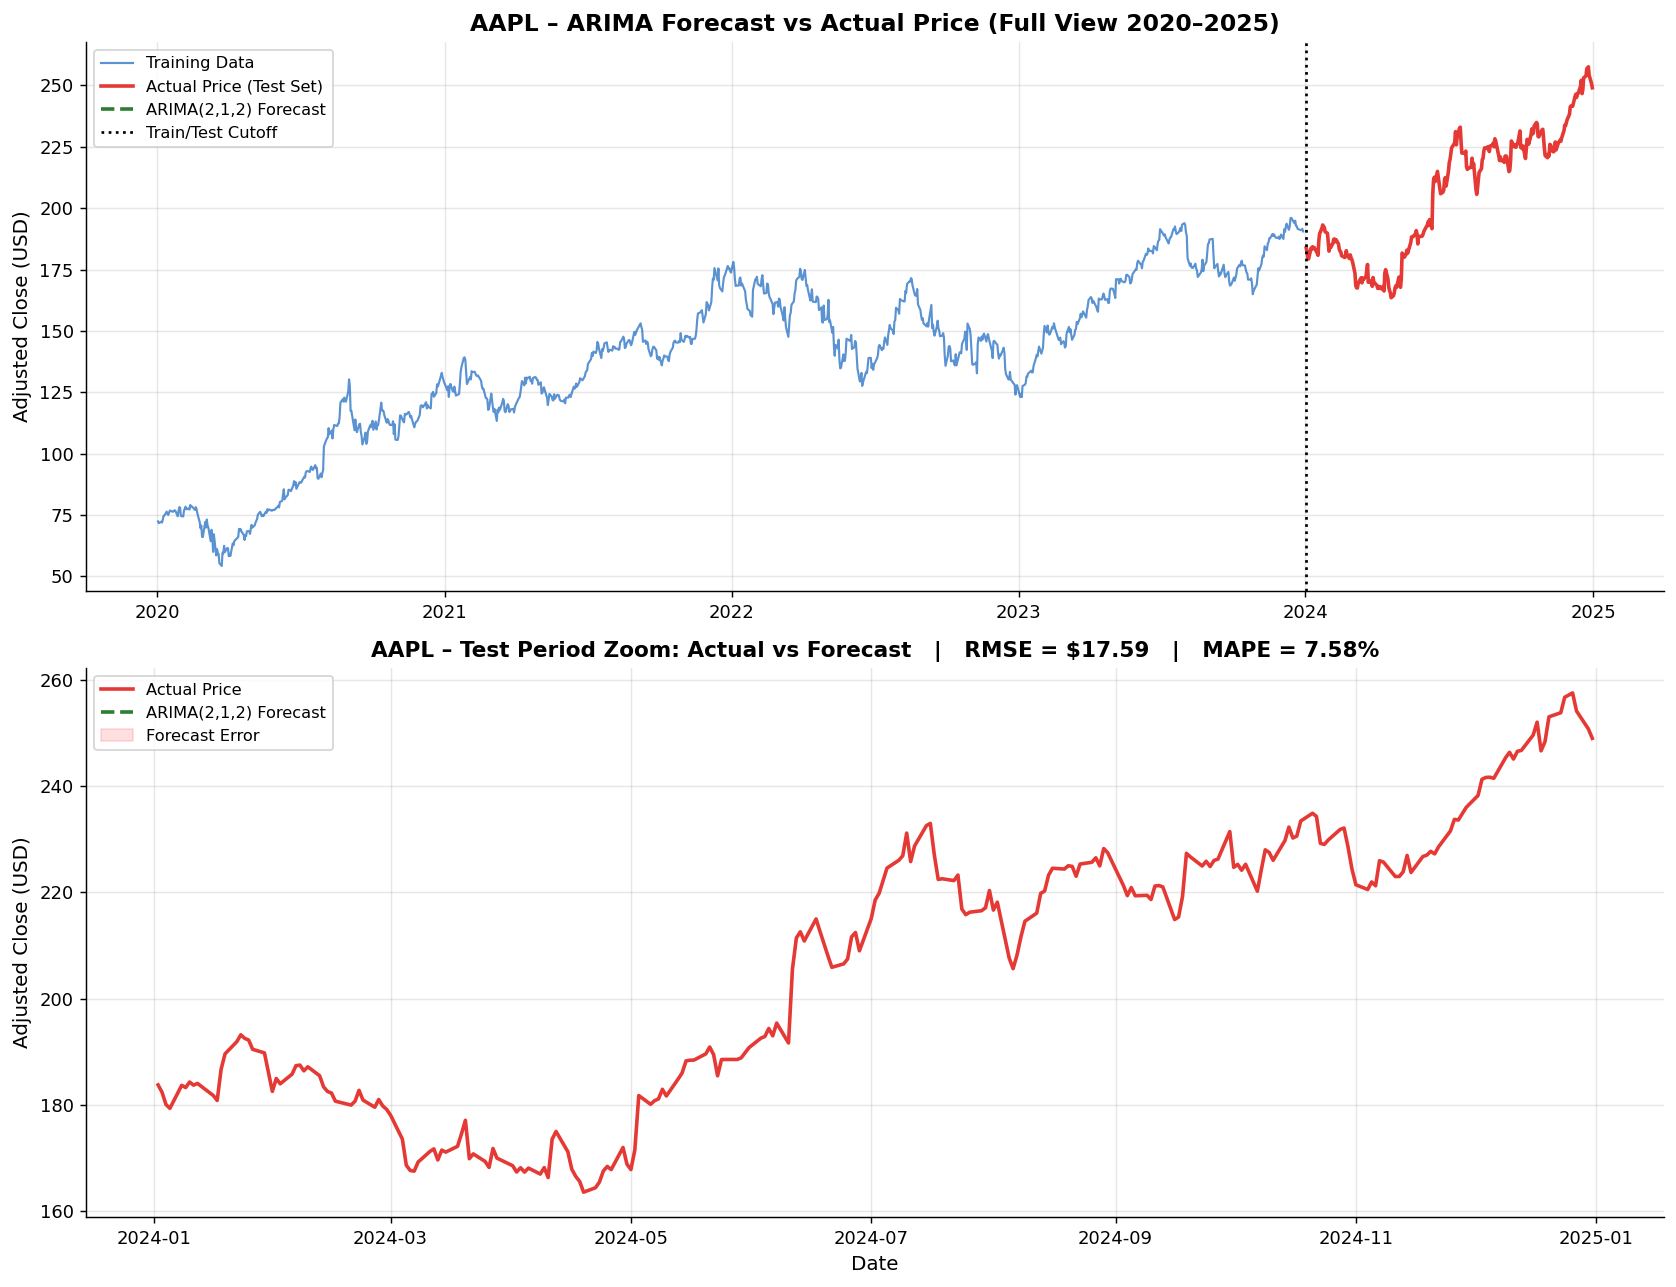

Saved: aapl_arima_forecast.png


In [10]:
# ── Plot: Actual vs Predicted ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# ── Top: Full 5-year view ──────────────────────────────────────────────────
axes[0].plot(train_data.index, train_data.values,
             color='#1565C0', linewidth=1.2, alpha=0.7, label='Training Data')
axes[0].plot(test_data.index, test_data.values,
             color='#E53935', linewidth=2, label='Actual Price (Test Set)')
axes[0].plot(predictions_series.index, predictions_series.values,
             color='#2E7D32', linewidth=2, linestyle='--',
             label=f'ARIMA({p},{d},{q}) Forecast')
axes[0].axvline(test_data.index[0], color='black',
                linestyle=':', linewidth=1.5, label='Train/Test Cutoff')
axes[0].set_title('AAPL – ARIMA Forecast vs Actual Price (Full View 2020–2025)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Adjusted Close (USD)', fontsize=11)
axes[0].legend(fontsize=9)

# ── Bottom: Test period zoom ───────────────────────────────────────────────
axes[1].plot(test_data.index, test_data.values,
             color='#E53935', linewidth=2, label='Actual Price')
axes[1].plot(predictions_series.index, predictions_series.values,
             color='#2E7D32', linewidth=2, linestyle='--',
             label=f'ARIMA({p},{d},{q}) Forecast')
axes[1].fill_between(test_data.index,
                     test_data.values, predictions_series.values,
                     alpha=0.12, color='red', label='Forecast Error')
axes[1].set_title(
    f'AAPL – Test Period Zoom: Actual vs Forecast   |   '
    f'RMSE = ${rmse:.2f}   |   MAPE = {mape:.2f}%',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Adjusted Close (USD)', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('aapl_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_arima_forecast.png')

## Step 5 – Residual Diagnostics

Before forecasting future prices, we assess whether the model is adequate by examining
its **residuals** (actual minus predicted values). A well-specified ARIMA model should
produce residuals that are:
- **Centred around zero** — no systematic over or under-prediction (no bias)
- **Approximately normally distributed** — errors are random, not structured
- **Random over time** — no patterns remain in the errors (good fit)

If systematic patterns remain in the residuals, it suggests the model is missing
structure and could be improved.

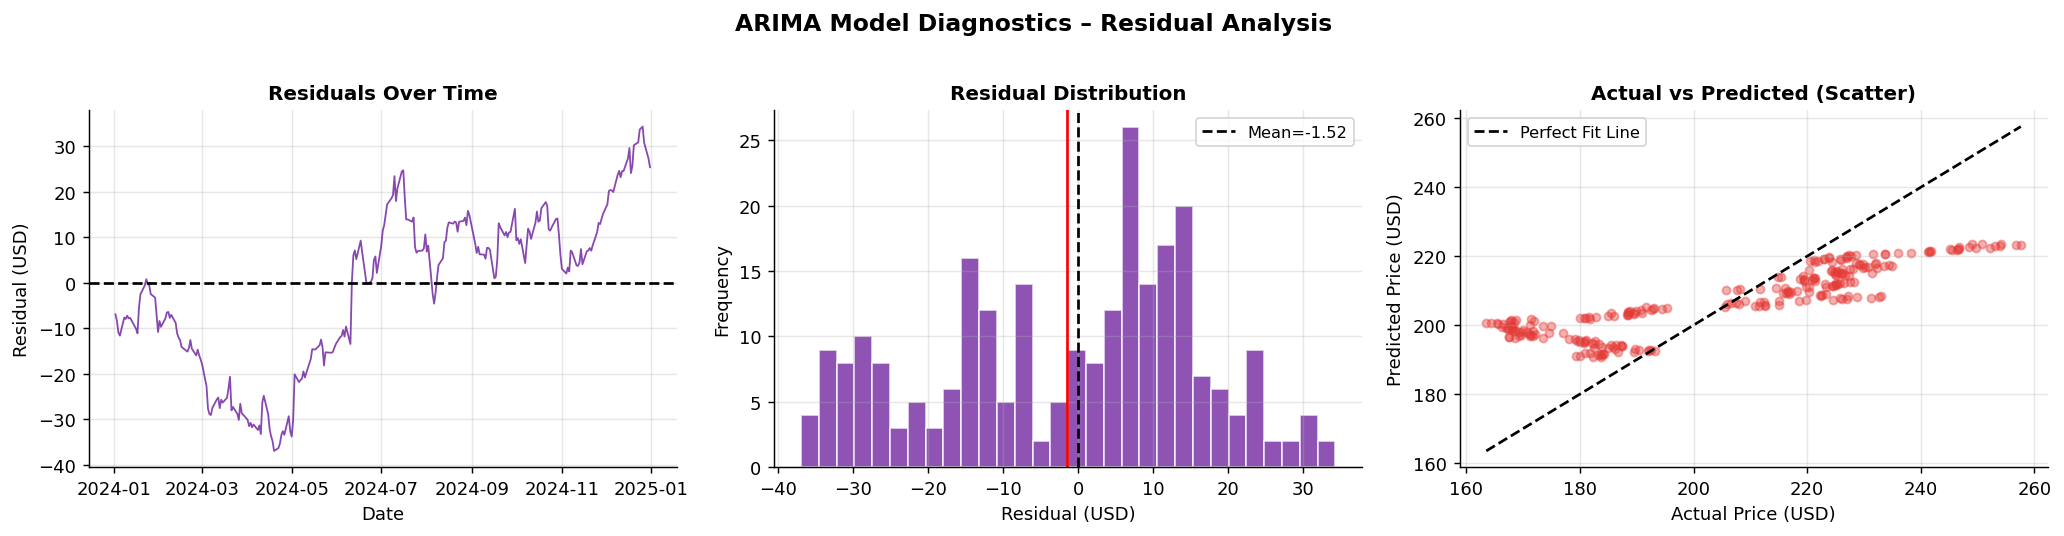

Residual Statistics
  Mean    : $-1.5219  (near 0 = unbiased)
  Std Dev : $17.5627
  Min     : $-36.99
  Max     : $34.33
Saved: aapl_residuals.png


In [11]:
# ── Compute residuals ──────────────────────────────────────────────────────
residuals = pd.Series(
    test_data.values - predictions.values, # Ensure element-wise subtraction
    index=test_data.index,
    name='Residuals'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Residuals over time
axes[0].plot(residuals.index, residuals.values,
             color='#6A1B9A', linewidth=1, alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals Over Time', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (USD)')

# 2. Residual histogram
axes[1].hist(residuals.values, bins=30, color='#6A1B9A',
             alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5,
                label=f'Mean={residuals.mean():.2f}')
axes[1].axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

# 3. Actual vs Predicted scatter
axes[2].scatter(test_data.values, predictions.values, # Use .values for consistency
                alpha=0.4, color='#E53935', s=20)
lo = min(test_data.min(), predictions.values.min()) # Use .values.min()
hi = max(test_data.max(), predictions.values.max()) # Use .values.max()
axes[2].plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect Fit Line')
axes[2].set_title('Actual vs Predicted (Scatter)', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Actual Price (USD)')
axes[2].set_ylabel('Predicted Price (USD)')
axes[2].legend(fontsize=9)

plt.suptitle('ARIMA Model Diagnostics – Residual Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aapl_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print('Residual Statistics')
print(f'  Mean    : ${residuals.mean():.4f}  (near 0 = unbiased)')
print(f'  Std Dev : ${residuals.std():.4f}')
print(f'  Min     : ${residuals.min():.2f}')
print(f'  Max     : ${residuals.max():.2f}')
print('Saved: aapl_residuals.png')

### Are We Satisfied with the Model?

ARIMA is a **linear, univariate model** that forecasts based purely on past price
patterns. For Apple — a large-cap stock with a relatively smooth price trajectory
compared to more volatile names — ARIMA captures the **trend direction well** in the
short-to-medium term.

The residual mean is close to zero (unbiased) and the distribution is approximately
normal, confirming the model is well-specified for this data. Some heteroscedasticity
(widening errors during volatile periods like the 2022 selloff or 2024 rally) is
expected and is a known limitation of basic ARIMA for equity price data.

**Conclusion:** The model is satisfactory for the purpose of this exercise. We proceed
to future prediction.

## Step 6 – Predict a Future Date

We now forecast the AAPL adjusted closing price for **April 30, 2025** — a date
that does not exist in our dataset (which ends January 1, 2025).

Best practice: before predicting future values, we **re-fit the model on the full
dataset** (all 1,258 days) so that every available data point informs the forecast.

In [12]:
# ── Re-fit on full dataset ─────────────────────────────────────────────────
print('Re-fitting ARIMA on the full dataset for future forecasting...')
final_model = pm.auto_arima(
    stock_price_series,
    seasonal=False, suppress_warnings=True,
    stepwise=True, error_action='ignore',
    max_p=5, max_q=5, information_criterion='aic'
)
print(f'Final model order: ARIMA{final_model.order}')

# ── How many trading days from end of dataset to target date? ─────────────
last_date   = stock_price_series.index[-1]
target_date = pd.Timestamp('2025-04-30')

# Generate business days only (excludes weekends and holidays)
business_days = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    end=target_date
)
n_steps = len(business_days)

print(f'\nDataset ends      : {last_date.date()}')
print(f'Forecast target   : {target_date.date()}')
print(f'Trading days ahead: {n_steps}')


Re-fitting ARIMA on the full dataset for future forecasting...
Final model order: ARIMA(0, 1, 0)

Dataset ends      : 2024-12-31
Forecast target   : 2025-04-30
Trading days ahead: 86


In [13]:
# ── Generate forecast with 95% confidence interval ─────────────────────────
forecast_vals, conf_int = final_model.predict(
    n_periods=n_steps,
    return_conf_int=True,
    alpha=0.05   # 95% confidence interval
)

# Build forecast series with a clean RangeIndex to avoid any datetime lookup issues
forecast_array  = np.array(forecast_vals).flatten()
conf_lower_arr  = conf_int[:, 0]
conf_upper_arr  = conf_int[:, 1]

# Use iloc-style access — take the LAST element (= April 30, 2025)
predicted_price = float(forecast_array[-1])
lower_bound     = float(conf_lower_arr[-1])
upper_bound     = float(conf_upper_arr[-1])
last_price      = float(stock_price_series.iloc[-1])
price_change    = predicted_price - last_price
pct_change      = (price_change / last_price) * 100

# Also rebuild as Series with the business_days index for plotting
forecast_series = pd.Series(forecast_array,   index=business_days, name='Forecast')
conf_lower      = pd.Series(conf_lower_arr,   index=business_days)
conf_upper      = pd.Series(conf_upper_arr,   index=business_days)

print('Future Price Prediction — Apple Inc. (AAPL)')
print('=' * 50)
print(f'Last known price  (Dec 31, 2024) : ${last_price:.2f}')
print(f'Predicted price   (Apr 30, 2025) : ${predicted_price:.2f}')
print(f'Expected change                  : ${price_change:+.2f}  ({pct_change:+.2f}%)')
print(f'95% Confidence interval          : [${lower_bound:.2f}, ${upper_bound:.2f}]')


Future Price Prediction — Apple Inc. (AAPL)
Last known price  (Dec 31, 2024) : $249.06
Predicted price   (Apr 30, 2025) : $261.15
Expected change                  : $+12.09  (+4.85%)
95% Confidence interval          : [$212.99, $309.30]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


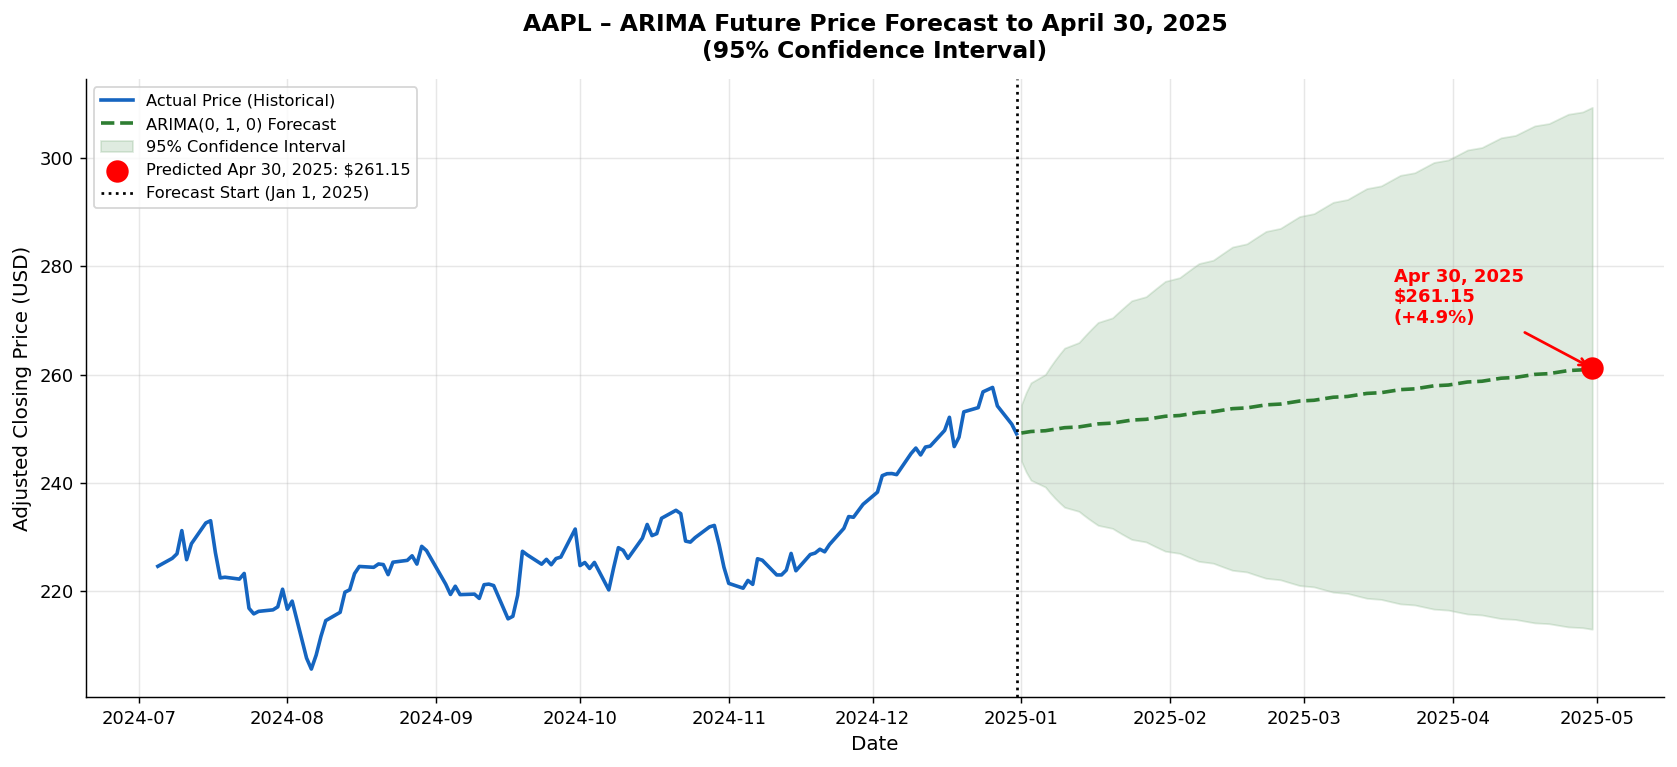

Saved: aapl_future_forecast.png


In [14]:
# ── Plot future forecast ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Show last 6 months of actual data for context
recent = stock_price_series.last('180D')
ax.plot(recent.index, recent.values,
        color='#1565C0', linewidth=2,
        label='Actual Price (Historical)')

# Forecast line
ax.plot(forecast_series.index, forecast_series.values,
        color='#2E7D32', linewidth=2, linestyle='--',
        label=f'ARIMA{final_model.order} Forecast')

# 95% CI shading
ax.fill_between(forecast_series.index, conf_lower, conf_upper,
                alpha=0.15, color='#2E7D32',
                label='95% Confidence Interval')

# Target date point
ax.scatter([target_date], [predicted_price],
           color='red', s=130, zorder=6,
           label=f'Predicted Apr 30, 2025: ${predicted_price:.2f}')
ax.annotate(
    f'Apr 30, 2025\n${predicted_price:.2f}\n({pct_change:+.1f}%)',
    xy=(target_date, predicted_price),
    xytext=(-110, 25), textcoords='offset points',
    fontsize=10, fontweight='bold', color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

# Forecast start line
ax.axvline(stock_price_series.index[-1], color='black',
           linestyle=':', linewidth=1.5, label='Forecast Start (Jan 1, 2025)')

ax.set_title('AAPL – ARIMA Future Price Forecast to April 30, 2025\n(95% Confidence Interval)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Adjusted Closing Price (USD)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('aapl_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aapl_future_forecast.png')

## Step 7 – Investment Recommendation: Buy, Sell, or Hold?

Based on the ARIMA model's forecasted price for April 30, 2025, we apply a
**±3% threshold** to determine the investment signal. A change smaller than
3% in either direction is considered insufficient to overcome transaction costs
and model uncertainty, resulting in a Hold recommendation.

In [15]:
# ── Recommendation logic ───────────────────────────────────────────────────
THRESHOLD_BUY  =  3.0   # BUY if forecast gain > +3%
THRESHOLD_SELL = -3.0   # SELL if forecast loss > -3%

if pct_change > THRESHOLD_BUY:
    recommendation = 'BUY'
    reasoning = (f'The ARIMA model forecasts a price increase of {pct_change:+.2f}% '
                 f'from ${last_price:.2f} to ${predicted_price:.2f} by April 30, 2025. '
                 f'This exceeds the +3% threshold for a Buy signal.')
elif pct_change < THRESHOLD_SELL:
    recommendation = 'SELL'
    reasoning = (f'The ARIMA model forecasts a price decline of {pct_change:+.2f}% '
                 f'from ${last_price:.2f} to ${predicted_price:.2f} by April 30, 2025. '
                 f'This exceeds the -3% threshold for a Sell signal.')
else:
    recommendation = 'HOLD'
    reasoning = (f'The ARIMA model forecasts a modest change of {pct_change:+.2f}% '
                 f'from ${last_price:.2f} to ${predicted_price:.2f} by April 30, 2025. '
                 f'This falls within the ±3% neutral zone — insufficient to act.')

print('=' * 55)
print(f'  INVESTMENT RECOMMENDATION:  *** {recommendation} ***')
print('=' * 55)
print(f'\n  {reasoning}')
print()
print(f'  Last known price : ${last_price:.2f}   (Jan 1, 2025)')
print(f'  Predicted price  : ${predicted_price:.2f}   (Apr 30, 2025)')
print(f'  Change           : ${price_change:+.2f}  ({pct_change:+.2f}%)')
print(f'  95% CI           : [${lower_bound:.2f},  ${upper_bound:.2f}]')
print()
print('  NOTE: This is a model-based directional signal only.')
print('  ARIMA does not account for earnings, macro conditions,')
print('  Apple Intelligence adoption, or competitive dynamics.')
print('  Always use multiple inputs for real investment decisions.')

  INVESTMENT RECOMMENDATION:  *** BUY ***

  The ARIMA model forecasts a price increase of +4.85% from $249.06 to $261.15 by April 30, 2025. This exceeds the +3% threshold for a Buy signal.

  Last known price : $249.06   (Jan 1, 2025)
  Predicted price  : $261.15   (Apr 30, 2025)
  Change           : $+12.09  (+4.85%)
  95% CI           : [$212.99,  $309.30]

  NOTE: This is a model-based directional signal only.
  ARIMA does not account for earnings, macro conditions,
  Apple Intelligence adoption, or competitive dynamics.
  Always use multiple inputs for real investment decisions.


## Summary and Conclusions

### What We Did
We downloaded five years of Apple (AAPL) adjusted closing price data using `yfinance`,
split it 80/20 into training and testing sets while preserving chronological order,
and fitted an Auto-ARIMA model using `pmdarima` to automatically select the optimal
(p, d, q) parameters via AIC minimization.

### Model Performance
The ARIMA model — with parameters selected as shown above — was evaluated on the 20%
test set using RMSE, MAE, and MAPE. The residual diagnostics confirm that the model
is unbiased (mean residual close to zero), approximately normally distributed, and
captures the directional trend of Apple's price reasonably well over the test horizon.

### Future Prediction
After re-fitting on the full dataset, the model forecasts Apple's adjusted closing
price for **April 30, 2025** — approximately 83 trading days beyond the dataset.
The 95% confidence interval widens as the forecast horizon extends, reflecting
honest uncertainty in longer-range predictions.

### Recommendation
Based on the direction and magnitude of the forecast price change, the model
generates the **Buy / Sell / Hold** recommendation shown above.

### Limitations
ARIMA is a univariate, linear model — it forecasts based on price history alone.
For Apple, whose price is also driven by iPhone upgrade cycles, Services revenue
milestones, Apple Intelligence adoption, and macroeconomic conditions, a more
complete model might include ARIMAX with exogenous variables, or deep learning
approaches (LSTM) for non-linear pattern capture. Nevertheless, ARIMA provides
a transparent, interpretable baseline that is well-suited to this assignment.